## import libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## get the data

In [3]:
df=pd.read_csv(r'C:housePrice.csv')
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


## see some details about data and delete nans

In [4]:
df.shape

(3479, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


In [6]:
df.isna().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [7]:
df.dropna(subset=['Address'],inplace=True)

In [8]:
df.isna().sum()

Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64

In [9]:
df.shape

(3456, 8)

In [10]:
df.Area.value_counts()

75                 111
100                103
90                  95
60                  94
105                 92
                  ... 
177                  1
221                  1
680                  1
 8,400,000,000       1
312                  1
Name: Area, Length: 243, dtype: int64

### delete strings from price column 

In [11]:
df = df[df['Area'].str.isdigit()]
df['Area'] = df['Area'].astype(int)

### convert the Addresses to numbers

In [12]:
df['Address'] = df['Address'].astype('category')

In [13]:
df['Address']=df['Address'].cat.codes

In [14]:
df.drop('Price(USD)',axis=1,inplace=True)

In [15]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63,1,True,True,True,156,1.850000e+09
1,60,1,True,True,True,156,1.850000e+09
2,79,2,True,True,True,117,5.500000e+08
3,95,2,True,True,True,152,9.025000e+08
4,123,2,True,True,True,150,7.000000e+09


### delete outliers from `price` column

In [16]:
from scipy import stats
z1 = np.abs(stats.zscore(df['Price']))
row_index2=np.where(z1 > 3)
df.drop(row_index2[0], inplace = True)

In [17]:
df.shape

(3371, 7)

In [18]:
df.nlargest(8,['Area'])

,Area,Room,Parking,Warehouse,Elevator,Address,Price
1694,929,5,True,True,False,188,8.000000e+10
1974,900,3,True,True,False,31,8.500000e+09
573,863,2,True,True,True,57,7.830000e+09
831,750,5,True,True,True,90,7.500000e+10
3115,750,5,True,True,False,178,3.500000e+09
1810,705,5,True,True,False,0,9.100000e+10
2481,700,3,True,True,False,31,4.500000e+09
2647,700,3,True,True,False,31,7.000000e+09


### add a new column

In [19]:
df['perSquare']= df['Price'] / df['Area']

In [20]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,perSquare
0,63,1,True,True,True,156,1.850000e+09,2.936508e+07
1,60,1,True,True,True,156,1.850000e+09,3.083333e+07
2,79,2,True,True,True,117,5.500000e+08,6.962025e+06
3,95,2,True,True,True,152,9.025000e+08,9.500000e+06
4,123,2,True,True,True,150,7.000000e+09,5.691057e+07


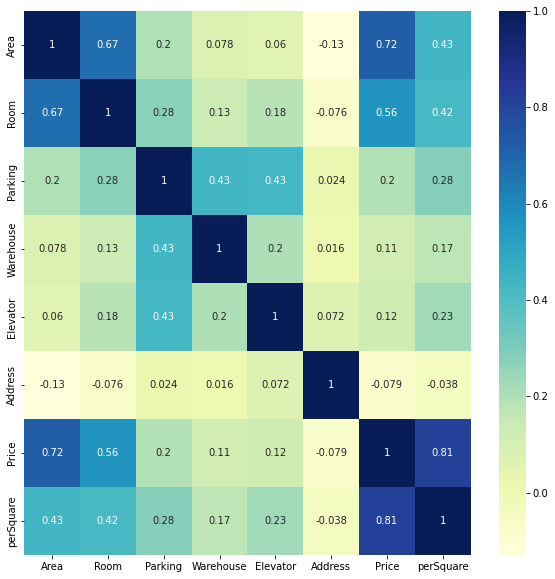

In [21]:
fig,ax=plt.subplots(figsize=(10,10))
corrMatrix = df.corr()
sns.heatmap(corrMatrix, annot=True,cmap="YlGnBu")
plt.show()

# modeling with `linear regression` , `lasso` and `elastic`

In [22]:
from sklearn.model_selection import train_test_split
np.random.seed(7)
X=df.drop('Price',axis=1)
y=df['Price']
train_x,test_x,train_y,test_y=train_test_split(X,y,test_size=0.2)

In [23]:
from sklearn.linear_model import LinearRegression
lineReg=LinearRegression()
lineReg.fit(train_x,train_y)

LinearRegression()

In [24]:
y_pred=lineReg.predict(test_x)

In [25]:
from sklearn.metrics import r2_score
r2_score(test_y,y_pred)

0.8617952862793564

In [26]:
from sklearn.linear_model import ElasticNet
elasticReg=ElasticNet(alpha=0.1,max_iter=2000)
elasticReg.fit(train_x,train_y)

ElasticNet(alpha=0.1, max_iter=2000)

In [27]:
y_preds=elasticReg.predict(test_x)
r2_score(test_y,y_preds)

0.863104944376132

In [28]:
from sklearn import linear_model
lassoReg = linear_model.Lasso(alpha=0.1,max_iter=2000)
lassoReg.fit(train_x,train_y)

Lasso(alpha=0.1, max_iter=2000)

In [29]:
y_pred_=elasticReg.predict(test_x)
r2_score(test_y,y_pred_)

0.863104944376132

## cross validation score for three models

In [30]:
from sklearn.model_selection import cross_val_score
lregScore = cross_val_score(lineReg, X, y, cv=5,scoring='r2')
elregScore = cross_val_score(elasticReg, X, y, cv=5,scoring='r2')
lssoregScore = cross_val_score(lassoReg, X, y, cv=5,scoring='r2')

C:\Users\Mostafa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.505e+22, tolerance: 1.723e+19
  model = cd_fast.enet_coordinate_descent(
C:\Users\Mostafa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.462e+22, tolerance: 1.650e+19
  model = cd_fast.enet_coordinate_descent(
C:\Users\Mostafa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

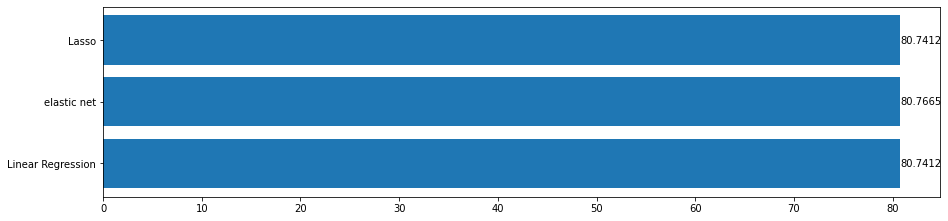

In [31]:
comparedict = {
  "Linear Regression": np.mean(lregScore)*100 ,
  "elastic net": np.mean(elregScore)*100,
  "Lasso": np.mean(lssoregScore)*100
}
fig, ax = plt.subplots(figsize=(15,3.5))
bars = ax.barh(range(len(comparedict)), list(comparedict.values()))
plt.yticks(range(len(comparedict)), list(comparedict.keys()))
for bars in ax.containers:
    ax.bar_label(bars)

`elastic` is a better model for this prediction